# Membrane fluctuations without the fixed-lattice assumption

`membrane_fluctuations_cpu.ipynb` transforms the height column of the vertex
array and takes each sample's $(x, y)$ from the **ideal lattice**. That is exact
today, because `DynamicModel::next_step()` builds a three-component displacement
and then throws two of them away, so the vertices never move in plane. It stops
being exact the moment anything moves them.

This notebook removes the assumption instead of documenting it. It evaluates the
Loop **limit surface itself**, inverts $\mathbf{S}_{xy}(v,w) = (x,y)$ for the
barycentric coordinate that lands on a requested point, and reads $z$ there. The
field that reaches the FFT is then a genuine Monge height $h(x,y)$ on a grid
*we* choose, and the choice is independent of where the control points have
drifted to.

Three things follow, and each is checked below rather than asserted:

1. On today's frozen lattice the new route reproduces the old answer **to
   machine precision** — so this is a generalisation, not a different
   measurement.
2. Resampling onto a plain rectangular grid retires `tile_fft2`'s half-cell
   phase: a bare `np.fft.fft2` becomes correct, because the sampling positions
   are ours.
3. Once the vertices do move, the old route's $|q|^{-4}$ tail degrades and the new
   one does not.

### Notes
- Everything specific to resampling lives in `analysis/membrane_resample.py`;
  the spectrum machinery is still `analysis/membrane_spectrum.py`.
- The 12 box-spline basis functions are transcribed from
  `get_shapefunction()` in `src/mesh/Gauss_quadrature.cpp`, so this evaluates
  the surface SLIMED integrates, not a re-derivation of it.

In [1]:
import os
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle


def find_repo_root(start=None):
    """The SLIMED checkout this notebook sits in, wherever it is run from."""
    here = Path(start or Path.cwd()).resolve()
    for d in (here, *here.parents):
        if (d / "CMakeLists.txt").is_file() and (d / "EXEs").is_dir():
            return d
    raise RuntimeError(f"no SLIMED checkout at or above {here}")


REPO = find_repo_root()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "analysis"))
import membrane_spectrum as ms
import membrane_resample as mr

# Where the dynamics runs live.  Section 0 puts them here, made by this
# machine's own OpenMP CPU build.  Set SLIMED_RUNS to analyse runs made
# somewhere else instead -- on a cluster, say -- and section 0 will keep any
# it finds already finished.
RUNS = Path(os.environ.get("SLIMED_RUNS", Path.home() / "slimed_runs"))
RUNS.mkdir(parents=True, exist_ok=True)

KBT = 4.17          # pN.nm, as in input.params
NBLOCK = 8          # blocks used for every error bar in this notebook

print("repo:", REPO)
print("runs:", RUNS)
print(sorted(p.name for p in RUNS.iterdir() if p.is_dir()))

repo: /Users/yue/Workspace/SLIMED
runs: /Users/yue/slimed_runs
['fast_test', 'pure_a', 'tension']


In [2]:
# --- slide styling ----------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "font.size": 17,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.labelspacing": 0.35,
    "lines.linewidth": 2.6,
    "lines.markersize": 9,
    "axes.linewidth": 1.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 7, "ytick.major.size": 7,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.minor.size": 4, "ytick.minor.size": 4,
    "errorbar.capsize": 3,
})

TEAL  = "#0f766e"
BRICK = "#b1442a"
OCHRE = "#a07a12"
INK   = "#111827"
GREY  = "#8d9794"


def nice_logx(*axes):
    """Plain numbers on a log axis: 0.1, 0.2, 0.3 ... not 2 x 10^-1."""
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    fmt = FuncFormatter(lambda v, _: f"{v:g}")
    cand = [m * 10.0 ** d for d in range(-6, 6) for m in (1, 1.5, 2, 3, 5, 7)]
    for ax in axes:
        lo, hi = ax.get_xlim()
        ticks = [c for c in cand if lo <= c <= hi]
        if len(ticks) >= 3:
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(NullLocator())
            ax.xaxis.set_major_formatter(fmt)


def unique_modes(lat):
    """One representative per conjugate pair, and never the q = 0 mode.

    For a real height field |h_{-q}|^2 equals |h_q|^2 in every frame, so the
    two are the same datapoint, not two.
    """
    keep = np.zeros((lat.ny, lat.nx), bool)
    seen = set()
    for iy in range(lat.ny):
        for ix in range(lat.nx):
            if (iy, ix) == (0, 0):
                continue
            if ((-iy) % lat.ny, (-ix) % lat.nx) in seen:
                continue
            seen.add((iy, ix))
            keep[iy, ix] = True
    return keep


# --- how far up in q the continuum law may be fitted ------------------------
# |q|*dFaceX = pi is the Nyquist wavevector of the mesh spacing, so pi/2 is half
# of it: four mesh cells per wavelength.  That the discretisation is still
# faithful there is measured, not assumed -- tests/test_continuum_limit.cpp
# puts an exact plane wave on the control net, reads the bending energy the
# production code returns, and refers the stiffness to the limit surface.
QDX_MAX = np.pi / 2

# |q|*dFaceX -> K_S(|q|) / (A kc |q|^4), from tests/test_continuum_limit.cpp.
# A function of |q|*dFaceX alone: the same numbers come back on a mesh twice as
# fine.  1 where the mesh is faithful; 0.995 at pi/2.
FORM_FACTOR = np.array([
    [0.000, 1.0000], [0.403, 1.0000], [0.603, 0.9999], [0.898, 0.9992],
    [1.209, 0.9979], [1.346, 0.9953], [1.612, 0.9919], [1.810, 0.9845],
    [2.015, 0.9754], [2.244, 0.9497], [2.418, 0.9355], [2.821, 0.8509],
    [3.225, 0.7002],
])


def form_factor(q_mag, d_face_x):
    """How much softer than the continuum this mesh is at |q|."""
    return np.interp(q_mag * d_face_x, FORM_FACTOR[:, 0], FORM_FACTOR[:, 1])


print(f"continuum window: |q|*dFaceX <= pi/2 = {QDX_MAX:.4f}"
      f"  (lambda >= 4 cells; lattice error {1-form_factor(QDX_MAX, 1.0):.1%})")

continuum window: |q|*dFaceX <= pi/2 = 1.5708  (lambda >= 4 cells; lattice error 0.8%)


---
## 0. The runs on the CPU

Everything below is measured from three trajectories of the same 100 nm
periodic box. They are produced by CPU build
with OpenMP on — `cmake -DSLIMED_ENABLE_OPENMP=ON`, and `forceBackend = cpu` in
every `input.params`.

| run | what it is | steps | frame every |
| --- | --- | ---: | ---: |
| `pure_a` | $\mu_S=0$, the equilibrium spectrum | 800 000 | 100 |
| `tension` | $\mu_S=250$ pN/nm, section 6 | 800 000 | 100 |
| `fast_test` | $\mu_S=0$, for the fast modes in section 7 | 60 000 | 1 |

`run_dynamics_flat` takes no arguments — it reads `./input.params` and writes
fixed output names — so each run gets its own directory and is launched from
inside it.

**Note** : OpenMP threading buys little here (the dense `surface2mesh` multiply
dominates and does not thread, see the performance note in
`docs/fluctuation_spectrum.md`), so the three runs are started as concurrent
processes with a few threads each rather than one after another.

Expect roughly **40 minutes** and **2 GB**.

In [3]:
BUILD = REPO / "build-omp"
EXE = BUILD / "bin" / "membrane_dynamics"

# 1.0 is the length the measurement actually needs; see the note above.  It
# shortens the two long runs only -- fast_test is three minutes either way,
# and section 7 has no fast modes to time without it.
SCALE = float(os.environ.get("SLIMED_STEPS_SCALE", 1.0))

# A 100 nm box on a 5 nm mesh: nFace 20 x 24, so a 14 x 18 periodic tile.
COMMON = {
    "boundaryType": "Periodic",
    "isFlat": "true",
    "lFace": 5.0,
    "sideX": 100.0,
    "sideY": 100.0,
    "kcMembraneBending": 83.4,      # 20 kT
    "c0Membrane": 0.0,
    "uvVolumeConstraint": 0.0,
    "isGlobalConstraint": "true",
    "setRelaxAreaToDefault": "true",
    "KBT": KBT,
    "timeStep": 0.002,              # us
    "diffConst": 1.0,               # nm^2/us
    "forceBackend": "cpu",          # the CPU loops, not the CUDA backend
    "fdtConsistentSurfaceUpdate": "true",    # section 3 of the doc: all three
    "integratePeriodicDuplicates": "false",  # fixes on
    "thermalFluctuationEnabled": "false",    # Brownian dynamics, not Metropolis
    "isInsertionIncluded": "false",
    "isEnergyHarmonicBondIncluded": "false",
    "isGagScaffoldingEnergyIncluded": "false",
    "isIdealizedProteinLatticeEnergyIncluded": "false",
    "meshpointOutput": "true",
    "xyzOutput": "false",
    "VERBOSE_MODE": "false",
}

SPECS = {
    "pure_a":      {"usMembraneStretching": 0.0,   "maxIterations": 800_000,
                    "meshpointOutputInterval": 100, "randomSeed": 101},
    "tension":     {"usMembraneStretching": 250.0, "maxIterations": 800_000,
                    "meshpointOutputInterval": 100, "randomSeed": 202},
    "fast_test": {"usMembraneStretching": 0.0,   "maxIterations": 60_000,
                    "meshpointOutputInterval": 1,   "randomSeed": 303},
}
SCALABLE = ("pure_a", "tension")


def openmp_binary():
    """build-omp/bin/membrane_dynamics, configuring and building if need be."""
    cache = BUILD / "CMakeCache.txt"
    on = cache.is_file() and "SLIMED_ENABLE_OPENMP:BOOL=ON" in cache.read_text()
    if on and EXE.is_file():
        return EXE
    if not on:
        cmake("-S", str(REPO), "-B", str(BUILD),
              "-DSLIMED_ENABLE_OPENMP=ON", "-DCMAKE_BUILD_TYPE=Release")
    cmake("--build", str(BUILD), "--target", "membrane_dynamics",
          "-j", str(os.cpu_count() or 4))
    return EXE


def cmake(*args):
    p = subprocess.run(["cmake", *args], capture_output=True, text=True)
    if p.returncode:
        raise RuntimeError("cmake " + " ".join(args) + " failed:\n"
                           + (p.stdout + p.stderr)[-2000:])


def params_text(name, spec):
    p = dict(COMMON, **spec)
    if name in SCALABLE:
        p["maxIterations"] = max(2000, int(p["maxIterations"] * SCALE))
    return "".join(f"{k} = {v}\n" for k, v in p.items())


MARKER = ".made-by-this-notebook"


def state(d, text):
    """"missing", "finished", "stale", or "foreign".

    A run this notebook made itself is remade when the parameters above
    change; one it did not make is never touched, whatever it holds.
    SLIMED_RUNS may well point at trajectories from somewhere else, and those
    are exactly the ones worth keeping.
    """
    if not ((d / "inputvertex_final.csv").is_file()
            and (d / "meshpointinput.csv").is_file()):
        return "missing"
    pf = d / "input.params"
    if pf.is_file() and pf.read_text() == text:
        return "finished"
    return "stale" if (d / MARKER).is_file() else "foreign"


def last_iteration(log):
    """The step count the run is on, from the tail of its own stdout."""
    try:
        with open(log, "rb") as f:
            f.seek(0, os.SEEK_END)
            f.seek(max(0, f.tell() - 8192))
            hits = re.findall(rb"ITERATION:(\d+)", f.read())
        return int(hits[-1]) + 1 if hits else 0
    except OSError:
        return 0


def generate(specs=SPECS, poll=15.0):
    exe = openmp_binary()
    threads = max(1, min(4, (os.cpu_count() or 4) // max(1, len(specs))))
    jobs = {}
    for name, spec in specs.items():
        d = RUNS / name
        d.mkdir(parents=True, exist_ok=True)
        text = params_text(name, spec)
        st = state(d, text)
        if st in ("finished", "foreign"):
            note = "" if st == "finished" else (
                "  (not made here, and its parameters differ -- "
                "delete the directory to regenerate)")
            print(f"{name:12s} finished already, keeping it{note}")
            continue
        if st == "stale":
            print(f"{name:12s} parameters changed, running it again")
        (d / "input.params").write_text(text)
        (d / MARKER).touch()
        for stale in ("inputvertex_final.csv", "meshpointinput.csv",
                      "surfacepointinput.csv"):
            (d / stale).unlink(missing_ok=True)
        log = open(d / "run.log", "w")
        proc = subprocess.Popen([str(exe)], cwd=d, stdout=log,
                                stderr=subprocess.STDOUT,
                                env=dict(os.environ,
                                         OMP_NUM_THREADS=str(threads)))
        jobs[name] = (proc, log, int(re.search(r"maxIterations = (\d+)",
                                               text).group(1)))
        print(f"{name:12s} started, {jobs[name][2]:,} steps")

    t0 = time.time()
    while any(p.poll() is None for p, _, _ in jobs.values()):
        time.sleep(poll)
        done = " ".join(f"{n} {last_iteration(RUNS / n / 'run.log') / tot:5.1%}"
                        for n, (_, _, tot) in jobs.items())
        print(f"\r  {time.time() - t0:5.0f} s   {done}", end="", flush=True)
    for name, (proc, log, _) in jobs.items():
        log.close()
        if proc.returncode:
            raise RuntimeError(f"{name} exited {proc.returncode}; see "
                               f"{RUNS / name / 'run.log'}")
    if jobs:
        print(f"\r  {time.time() - t0:5.0f} s   all runs finished" + " " * 20)


generate()
print(f"threads per run: {max(1, min(4, (os.cpu_count() or 4) // len(SPECS)))}"
      f" of {os.cpu_count()}; scale {SCALE:g}")

pure_a       finished already, keeping it
tension      finished already, keeping it
fast_test    finished already, keeping it
threads per run: 3 of 10; scale 1


---
## 1. The assumption being removed

`Dynamic_model.cpp` assembles a displacement for all three axes and then zeroes
two of them:

```cpp
if (j < 2) { randomterm *= 0.0; forceterm *= 0.0; }
```

so neither the force nor the noise ever acts in plane. Whatever in-plane motion
survives is round-off from the `surface2mesh * mesh2surface` round trip, which
returns the $x, y$ columns to themselves up to the conditioning of a dense
inverse.

That is worth measuring rather than trusting, because the height reader never
looks at the $x, y$ columns at all — a drift would be **silent**. A displacement
$\boldsymbol\delta$ enters the transform as a per-site phase
$e^{i\mathbf q\cdot\boldsymbol\delta}$: a Debye–Waller-like loss of coherent
amplitude, with the lost power scattered diffusely across every mode. The
fitting window barely notices. The $|q|^{-4}$ tail sits four decades down and is
contaminated by whatever leaks out of the low-$|q|$ modes — the same failure mode
as dropping the zig-zag phase.

In [4]:
RUN = RUNS / "pure_a"
lat = ms.lattice_from_params(RUN / "input.params")

par = {}
for line in open(RUN / "input.params"):
    if "=" in line and not line.strip().startswith("#"):
        k, v = line.split("=", 1)
        par[k.strip()] = v.split("#")[0].strip()
KC_IN = float(par["kcMembraneBending"])
DIFF = float(par["diffConst"])
DT_FRAME = float(par["timeStep"]) * int(par.get("meshpointOutputInterval", 1))
A_CELL = lat.area / (lat.nx * lat.ny)          # area per vertex, for the mobility

# Control nets sampled across the run, all three columns this time.  Lines that
# are not wanted are skipped without being parsed, so a coarse stride over the
# whole trajectory is cheap.
ends = mr.read_tile_control(RUN / "meshpointinput.csv", lat, stride=200)
d = np.abs(ends[-1] - ends[0])

print(lat.describe())
print(f"\nbetween the first and last of {len(ends)} sampled frames, per vertex:")
print(f"  max |dx| = {d[..., 0].max():.2e} nm")
print(f"  max |dy| = {d[..., 1].max():.2e} nm      <- in-plane: round-off only")
print(f"  max |dz| = {d[..., 2].max():.2f} nm        <- the physics")
print(f"\nin-plane drift is {d[..., 1].max() / d[..., 2].max():.0e} of the height "
      f"excursion, so the vertex-based transform is exact here.")
print("Everything below is about not depending on that.")

mesh 21 x 25 vertices (nFace 20 x 24), cell 5 x 4.33013 nm
periodic tile 14 x 18 = 252 vertices, Lx = 70 nm, Ly = 77.9423 nm, A = 5455.96 nm^2

between the first and last of 41 sampled frames, per vertex:
  max |dx| = 1.60e-09 nm
  max |dy| = 1.00e-07 nm      <- in-plane: round-off only
  max |dz| = 3.36 nm        <- the physics

in-plane drift is 3e-08 of the height excursion, so the vertex-based transform is exact here.
Everything below is about not depending on that.


---
## 2. The patch, and where its twelve nodes are

Every interior vertex of the flat mesh has valence 6, so every face carries the
**regular** 12-node Loop patch: a quartic box spline
$\mathbf{S}(v,w) = \sum_{k=0}^{11} N_k(v,w)\,\mathbf{p}_k$ over barycentric
coordinates with $u = 1 - v - w$.

The basis functions come straight from the C++. Their *layout* — which mesh
vertex is node $k$ — was not guessed either. Every box spline reproduces affine
functions exactly, so

$$\sum_k N_k(v,w)\,\mathbf{r}_k = \text{affine}(v,w)$$

has a unique solution for the twelve unknown $\mathbf{r}_k$, and it puts them on
the integer triangular lattice. Solving it is the cell below: if the ordering in
`membrane_resample.PATCH_SHEARED` were wrong, the nodes would not land on
lattice sites and the residual would not be $10^{-16}$.

In [5]:
# Corner masks: at a parameter corner the patch must collapse to the Loop limit
# rule, 1/2 the vertex plus 1/12 of each of its six neighbours.
print("weights at the three parameter corners:")
for name, (vv, ww) in {"u=1": (0., 0.), "v=1": (1., 0.), "w=1": (0., 1.)}.items():
    N = mr.shape_functions(np.array(vv), np.array(ww))[0]
    centre = [k for k in range(12) if abs(N[k] - 0.5) < 1e-12]
    ring = [k for k in range(12) if abs(N[k] - 1 / 12) < 1e-12]
    print(f"  {name}:  node {centre[0]:2d} carries 1/2,  nodes {ring} carry 1/12"
          f"   (sum {N.sum():.12f})")

# Linear precision: solve for the node positions and check they are lattice sites.
a1, a2 = np.array([1.0, 0.0]), np.array([0.5, np.sqrt(3) / 2])
rng = np.random.default_rng(1)
v = rng.uniform(0, 1, 4000); w = rng.uniform(0, 1, 4000)
k = (v + w) < 1; v, w = v[k], w[k]
N = mr.shape_functions(v, w)[0]
target = v[:, None] * a1 + w[:, None] * a2      # corner u=1 sits at the origin
r, *_ = np.linalg.lstsq(N, target, rcond=None)
coef = np.linalg.solve(np.column_stack([a1, a2]), r.T).T

print(f"\nlinear-precision solve: residual {np.abs(N @ r - target).max():.1e}")
print(f"node positions land on the integer lattice to "
      f"{np.abs(coef - np.round(coef)).max():.1e}")
print(f"recovered layout matches PATCH_SHEARED: "
      f"{np.array_equal(np.round(coef).astype(int), mr.PATCH_SHEARED)}")

weights at the three parameter corners:
  u=1:  node  3 carries 1/2,  nodes [0, 1, 2, 4, 6, 7] carry 1/12   (sum 1.000000000000)
  v=1:  node  6 carries 1/2,  nodes [2, 3, 5, 7, 9, 10] carry 1/12   (sum 1.000000000000)
  w=1:  node  7 carries 1/2,  nodes [3, 4, 6, 8, 10, 11] carry 1/12   (sum 1.000000000000)

linear-precision solve: residual 9.2e-16
node positions land on the integer lattice to 2.0e-14
recovered layout matches PATCH_SHEARED: True


findfont: Failed to find font weight normal, now using 0.


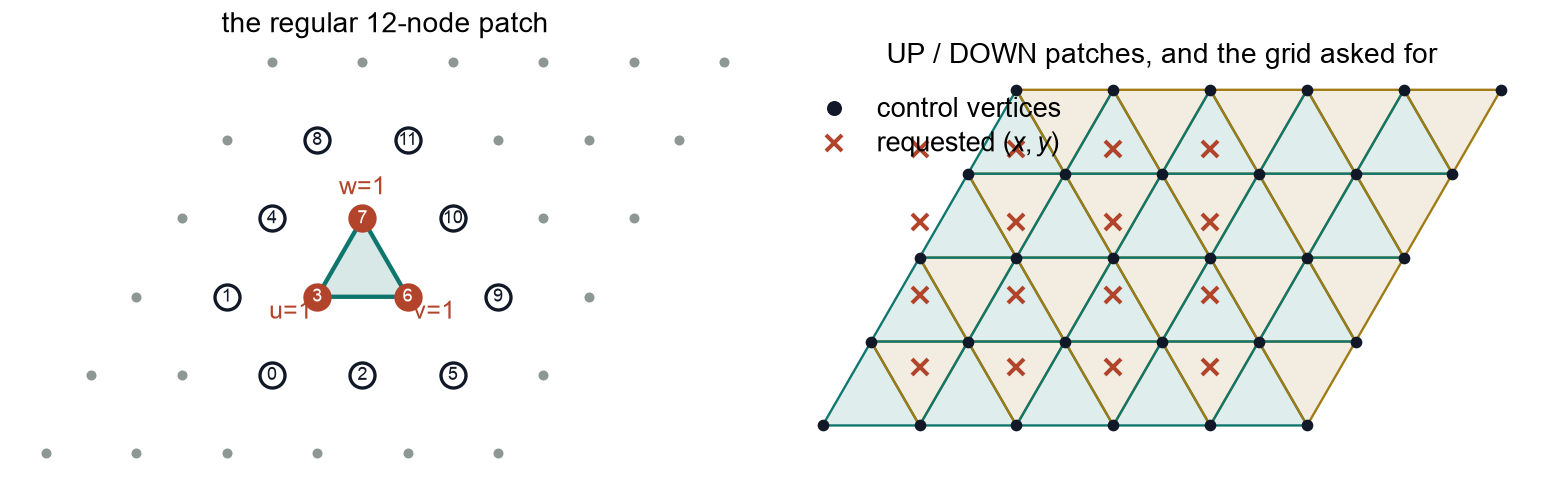

DOWN is the same stencil read through the 180-degree rotation about the
cell centre, which is a symmetry of the lattice -- so one stencil serves both.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))
a1, a2 = np.array([1.0, 0.0]), np.array([0.5, np.sqrt(3) / 2])


def xy(m, n):
    return m * a1 + n * a2


# -- left: the 12 nodes and the triangle they support ----------------------
ax = axes[0]
for m in range(-2, 4):
    for n in range(-2, 4):
        p = xy(m, n)
        ax.plot(*p, "o", ms=5, color=GREY, zorder=1)
tri = np.array([xy(0, 0), xy(1, 0), xy(0, 1), xy(0, 0)])
ax.fill(tri[:, 0], tri[:, 1], color=TEAL, alpha=0.16, zorder=0)
ax.plot(tri[:, 0], tri[:, 1], "-", color=TEAL, lw=2.6, zorder=3)
for k, (m, n) in enumerate(mr.PATCH_SHEARED):
    p = xy(m, n)
    corner = k in (mr.CORNER_U, mr.CORNER_V, mr.CORNER_W)
    ax.plot(*p, "o", ms=15, mfc=BRICK if corner else "white",
            mec=BRICK if corner else INK, mew=2.0, zorder=4)
    ax.text(*p, str(k), ha="center", va="center", fontsize=11, zorder=5,
            color="white" if corner else INK)
centre = tri[:3].mean(axis=0)
for lbl, k in (("u=1", mr.CORNER_U), ("v=1", mr.CORNER_V), ("w=1", mr.CORNER_W)):
    p = xy(*mr.PATCH_SHEARED[k])
    out = p - centre
    ax.text(*(p + 0.34 * out / np.linalg.norm(out)), lbl, ha="center",
            va="center", fontsize=15, color=BRICK, zorder=6)
ax.set_title("the regular 12-node patch", fontsize=17)

# -- right: how the patches tile, and what resampling asks of them ---------
ax = axes[1]
for m in range(0, 5):
    for n in range(0, 4):
        for kind, c in ((mr.UP, TEAL), (mr.DOWN, OCHRE)):
            t = (np.array([xy(m, n), xy(m + 1, n), xy(m, n + 1)]) if kind == mr.UP
                 else np.array([xy(m + 1, n), xy(m, n + 1), xy(m + 1, n + 1)]))
            t = np.vstack([t, t[:1]])
            ax.fill(t[:, 0], t[:, 1], color=c, alpha=0.13, lw=0)
            ax.plot(t[:, 0], t[:, 1], "-", color=c, lw=1.4)
for m in range(0, 6):
    for n in range(0, 5):
        ax.plot(*xy(m, n), "o", ms=6, color=INK, zorder=3)
gx, gy = np.meshgrid(np.arange(1.0, 4.01, 1.0), np.arange(0.6, 3.01, 0.75))
ax.plot(gx, gy, "x", color=BRICK, ms=10, mew=2.4, zorder=4)
ax.plot([], [], "o", color=INK, ms=8, label="control vertices")
ax.plot([], [], "x", color=BRICK, ms=10, mew=2.4, label="requested $(x,y)$")
ax.legend(loc="upper left")
ax.set_title("UP / DOWN patches, and the grid asked for", fontsize=17)

for ax in axes:
    ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout()
plt.show()

print("DOWN is the same stencil read through the 180-degree rotation about the")
print("cell centre, which is a symmetry of the lattice -- so one stencil serves both.")

---
## 3. Inverting $\mathbf{S}_{xy}(v,w) = (x,y)$

The map from barycentric coordinates to the plane is a **quartic**, so there is
no closed form to invert. There is no need for one: its Jacobian is the same box
spline differentiated, which the shape functions already carry, and Newton from
an affine seed converges quadratically. `LimitSurface.solve` seeds from the
ideal lattice, iterates, and walks to a neighbouring face for any point that
turns out to belong there — so the seed only has to be close, not right.

Two cheaper approximations are implemented for comparison, since the plan was to
fall back on one if the exact solve proved expensive:

| `method` | what it does |
|---|---|
| `"newton"` | inverts the quartic exactly, to $10^{-11}$ nm |
| `"limit"` | one affine solve in the triangle through the patch's three **limit** points |
| `"mesh"` | the same, through the three **control** points |

The benchmark below is the argument for not needing them.

In [7]:
# --- 1. exactness: on today's frozen lattice the new route must reproduce the old
net = mr.reference_net(RUN / "meshpointinput.csv", lat)
surf = mr.LimitSurface(lat, net)
print(f"folded control triangles: {surf.inverted_control_triangles()}"
      f"   (a fold would mean the surface is not a graph over the plane)")

z_probe = ms.read_tile_heights(RUN / "meshpointinput.csv", lat, stride=200)
R_vertex = surf.solve(*surf.monge_grid("zigzag"))
diff = np.abs(R_vertex.apply(z_probe) - ms.limit_surface_from_control(z_probe, lat))
interior = (slice(None), slice(2, -2), slice(2, -2))
print(f"\nresampled at the vertices vs limit_surface_from_control:")
print(f"  interior     max |diff| = {diff[interior].max():.2e} nm")
print(f"  whole tile   max |diff| = {diff.max():.2e} nm   "
      f"(seam only; the CSV carries 6 decimals)")
print(f"  field r.m.s.            = {z_probe.std():.3f} nm")

# --- 2. linear precision under a deformed net: the answer is known exactly
rng = np.random.default_rng(11)
A, B, C = 0.037, -0.021, 1.3
for sigma in (0.0, 0.25, 1.0):
    n2 = net.copy()
    if sigma:
        n2[..., :2] += rng.normal(scale=sigma, size=n2[..., :2].shape)
    n2[..., 2] = A * n2[..., 0] + B * n2[..., 1] + C          # an exact plane
    s2 = mr.LimitSurface(lat, n2)
    X, Y = s2.monge_grid("cartesian")
    R = s2.solve(X, Y)
    # only where the 12-node stencil does not cross the seam: a tilted plane is
    # not periodic, so it is not a valid reference across it
    keep = ~s2.crosses_seam(*R.faces)
    err = np.abs(R.apply(n2[..., 2]).ravel()[keep] - (A * X + B * Y + C).ravel()[keep])
    print(f"\nin-plane sigma = {sigma:4.2f} nm: xy-residual {R.residual:.1e} nm, "
          f"z error {err.max():.1e} nm over {keep.sum()} interior points")

# --- 3. what it costs
print("\ncost of the exact solve:")
for f in (1, 2, 4):
    X, Y = surf.monge_grid("cartesian", factor=f)
    t0 = time.time(); R = surf.solve(X, Y); dt = time.time() - t0
    print(f"  {X.size:5d} points  {dt * 1e3:6.1f} ms  ({dt / X.size * 1e6:4.1f} us/point,"
          f" {R.iterations} Newton sweeps)")

folded control triangles: 0   (a fold would mean the surface is not a graph over the plane)

resampled at the vertices vs limit_surface_from_control:
  interior     max |diff| = 8.88e-15 nm
  whole tile   max |diff| = 2.13e-08 nm   (seam only; the CSV carries 6 decimals)
  field r.m.s.            = 1.190 nm

in-plane sigma = 0.00 nm: xy-residual 1.4e-14 nm, z error 1.3e-15 nm over 165 interior points

in-plane sigma = 0.25 nm: xy-residual 2.4e-13 nm, z error 1.3e-15 nm over 164 interior points

in-plane sigma = 1.00 nm: xy-residual 2.8e-14 nm, z error 8.9e-16 nm over 165 interior points

cost of the exact solve:
    252 points     3.5 ms  (13.7 us/point, 3 Newton sweeps)
   1008 points    13.5 ms  (13.3 us/point, 5 Newton sweeps)
   4032 points    50.7 ms  (12.6 us/point, 6 Newton sweeps)


In [8]:
# How good are the cheap approximations, and do we need them?
z_rough = ms.read_tile_heights(RUN / "meshpointinput.csv", lat, stride=400)
rng = np.random.default_rng(7)
print(f"error against the exact solve, on a real height field "
      f"(r.m.s. {z_rough.std():.2f} nm):\n")
print(f"{'in-plane sigma':>15} {'% of cell':>10} {'limit':>12} {'mesh':>12}")
for sigma in (0.0, 0.05, 0.1, 0.25, 0.5):
    n2 = net.copy()
    if sigma:
        n2[..., :2] += rng.normal(scale=sigma, size=n2[..., :2].shape)
    s2 = mr.LimitSurface(lat, n2)
    X, Y = s2.monge_grid("cartesian")
    ref = s2.solve(X, Y).apply(z_rough)
    e = {m: np.abs(s2.solve(X, Y, method=m).apply(z_rough) - ref).max()
         for m in ("limit", "mesh")}
    print(f"{sigma:12.2f} nm {sigma / lat.d_face_x:9.1%} "
          f"{e['limit']:12.2e} {e['mesh']:12.2e}")

print("\nThe exact solve costs ~15 us/point once, and the parameter values depend")
print("only on the in-plane geometry -- so while that is frozen it is solved once")
print("and reused for every frame.  There is no reason to accept the approximations.")

error against the exact solve, on a real height field (r.m.s. 1.19 nm):

 in-plane sigma  % of cell        limit         mesh
        0.00 nm      0.0%     1.24e-14     2.12e-08
        0.05 nm      1.0%     5.38e-03     1.82e-02
        0.10 nm      2.0%     1.03e-02     3.92e-02
        0.25 nm      5.0%     3.31e-02     1.34e-01
        0.50 nm     10.0%     4.75e-02     2.32e-01

The exact solve costs ~15 us/point once, and the parameter values depend
only on the in-plane geometry -- so while that is frozen it is solved once
and reused for every frame.  There is no reason to accept the approximations.


---
## 4. Which grid to resample onto

Two choices, and the notebook uses both for different purposes.

**`"zigzag"`** is the vertex set itself — the control points' own $(x,y)$. It is
here to be compared against, not to be used: on a frozen lattice it must
reproduce `limit_surface_from_control` exactly, which is the check above.

**`"cartesian"`** is the grid the Monge gauge actually wants: a plain
rectangular lattice over the same box. It is the one used from here on, and it
buys something concrete. `tile_fft2` exists because the vertices sit on a
zig-zag lattice whose half-cell row offset a naive `fft2` silently drops. Choose
the sampling positions and that correction is not needed — a bare `np.fft.fft2`
is the whole transform.

The wavevectors change with it. A sampled mode is the family $\mathbf q +
\mathbf G$ with $\mathbf G$ the reciprocal lattice **of the grid that did the
sampling** — triangular for the vertex set, rectangular here — so
`cartesian_q_grid` folds differently from `q_grid`. Same bins, different labels
near the zone boundary.

In [9]:
# Every frame, not a subsample: section 8 times the slow modes from this same
# array, and a strided read would silently misstate the frame interval.
z = ms.read_tile_heights(RUN / "meshpointinput.csv", lat)
BURN = len(z) // 5
z_eq = z[BURN:]
print(f"{len(z)} frames read, discarding {BURN}, analysing {len(z_eq)} "
      f"= {len(z_eq) * DT_FRAME:.0f} us")

X_cart, Y_cart = surf.monge_grid("cartesian")
X_zig, Y_zig = surf.monge_grid("zigzag")
t0 = time.time(); R_cart = surf.solve(X_cart, Y_cart); t_solve = time.time() - t0
t0 = time.time(); h_cart = R_cart.apply(z_eq); t_apply = time.time() - t0

h_vertex = ms.limit_surface_from_control(z_eq, lat)      # the old route

print(f"\nsolve  {X_cart.size} grid points: {t_solve * 1e3:.0f} ms, "
      f"residual {R_cart.residual:.1e} nm, all placed: {bool(R_cart.converged.all())}")
print(f"apply  {len(z_eq)} frames:      {t_apply * 1e3:.0f} ms")
print(f"\nr.m.s. h: vertex route {h_vertex.std():.4f} nm, "
      f"resampled {h_cart.std():.4f} nm")

8001 frames read, discarding 1600, analysing 6401 = 1280 us

solve  252 grid points: 4 ms, residual 1.4e-14 nm, all placed: True
apply  6401 frames:      88 ms

r.m.s. h: vertex route 1.1472 nm, resampled 1.1455 nm


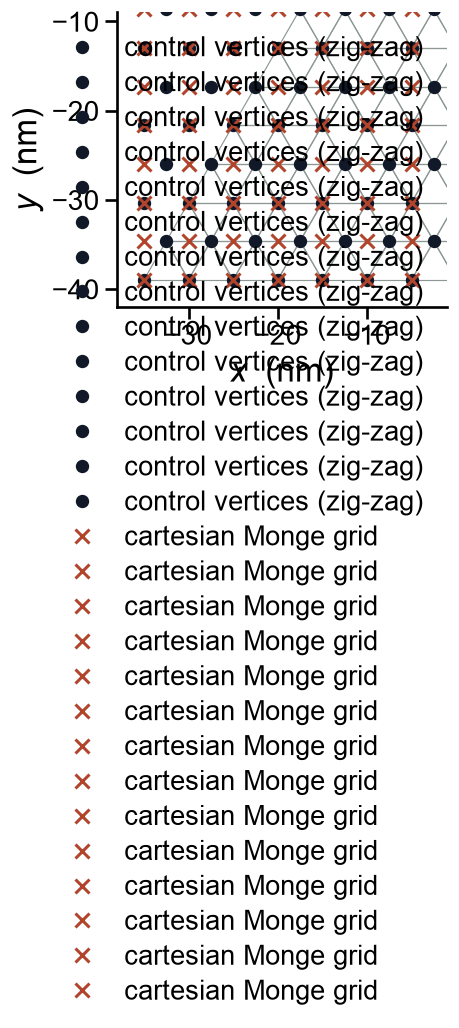

126 of 252 cartesian points sit exactly on a vertex -- the rows
that carry no half-cell offset -- and the other 126 fall at cell centres,
half a cell (2.5 nm) away.  Every one of them, coincident or not,
needed a patch and a (v, w) solved for it.


In [10]:
fig, ax = plt.subplots(figsize=(9.6, 6.4))

# the mesh, drawn from the run's own control net
P = net[..., :2]
mm, nn = np.meshgrid(np.arange(lat.nx), np.arange(lat.ny), indexing="xy")
mm, nn = mm.ravel(), nn.ravel()
segs = []
for kind in (mr.UP, mr.DOWN):
    c = surf.face_corners(mm, nn, np.full(mm.shape, kind))     # (nfaces, 3, 2)
    segs += [c[:, [0, 1]], c[:, [1, 2]], c[:, [2, 0]]]
ax.add_collection(LineCollection(np.concatenate(segs), colors=GREY,
                                 linewidths=0.7, zorder=1))

ax.plot(P[..., 0], P[..., 1], "o", ms=7, color=INK, zorder=3,
        label="control vertices (zig-zag)")
ax.plot(X_cart, Y_cart, "x", color=BRICK, ms=8, mew=1.8, zorder=4,
        label="cartesian Monge grid")
ax.set_xlim(net[..., 0].min() - 3, net[..., 0].min() + 34)
ax.set_ylim(net[..., 1].min() - 3, net[..., 1].min() + 30)
ax.set_aspect("equal")
ax.set_xlabel("$x$  (nm)"); ax.set_ylabel("$y$  (nm)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

same = np.abs(X_cart - X_zig) < 1e-9
print(f"{same.sum()} of {same.size} cartesian points sit exactly on a vertex -- the rows")
print(f"that carry no half-cell offset -- and the other {(~same).sum()} fall at cell centres,")
print(f"half a cell ({lat.d_face_x / 2:g} nm) away.  Every one of them, coincident or not,")
print("needed a patch and a (v, w) solved for it.")

---
## 5. The spectrum

Same reduction as the CPU notebook: one datapoint per conjugate pair, error bars
from eight equal time blocks of each mode's own series, the two-parameter fit of
$1/(AS) = (\kappa_c/k_BT)|q|^4 + (\sigma/k_BT)|q|^2$ inside $|q|\,d_x \le \pi/2$.

The only change is where $h$ came from.

In [11]:
def block_power(H, lat, nblock=NBLOCK):
    """<|h_q|^2> and its standard error over equal time blocks."""
    n = len(H)
    edges = np.linspace(0, n, nblock + 1).astype(int)
    per = np.array([np.mean(np.abs(H[a:b]) ** 2, axis=0)
                    for a, b in zip(edges[:-1], edges[1:])])
    per /= (lat.nx * lat.ny) ** 2
    return per.mean(axis=0), per.std(axis=0, ddof=1) / np.sqrt(nblock)


keep = unique_modes(lat)
results = {}
for tag, H, q2d in (
    ("vertex route", ms.tile_fft2(h_vertex, lat), ms.q_grid(lat)[2]),
    ("resampled, cartesian", np.fft.fft2(h_cart, axes=(-2, -1)),
     mr.cartesian_q_grid(lat)[2]),
):
    S2d, E2d = block_power(H, lat)
    qv, Sv, Ev = q2d[keep], S2d[keep], E2d[keep]
    o = np.argsort(qv); qv, Sv, Ev = qv[o], Sv[o], Ev[o]
    win = qv * lat.d_face_x <= QDX_MAX
    wgt = Sv[win] / np.maximum(Ev[win], 1e-30)
    slope, icept = np.polyfit(np.log10(qv[win]), np.log10(Sv[win]), 1, w=wgt)
    kc, sigma = ms.fit_kc_sigma(qv[win], Sv[win], lat.area, KBT)
    results[tag] = dict(q=qv, S=Sv, E=Ev, win=win, order=o, slope=slope,
                        icept=icept, kc=kc, sigma=sigma)
    print(f"{tag:22s} {win.sum():3d} modes in window   slope {slope:+.3f}   "
          f"kc {kc:6.2f} pN.nm ({kc / KBT:4.1f} kT)   sigma {sigma:+.3f} pN/nm")

print(f"\ninput kc = {KC_IN} pN.nm ({KC_IN / KBT:.0f} kT)")
a, b = results["vertex route"], results["resampled, cartesian"]
print(f"the two routes differ by {abs(a['kc'] - b['kc']) / a['kc']:.2%} in kc")

# The resampled route is this notebook's answer; everything below reduces it.
# `order` sorts the kept modes by |q|, so a 2-D array indexed [keep][order]
# lines up with qv element for element.
_, _, q_cart = mr.cartesian_q_grid(lat)
res = results["resampled, cartesian"]
qv, Sv, Ev, win, order = res["q"], res["S"], res["E"], res["win"], res["order"]
qq = np.logspace(np.log10(qv.min() * 0.85), np.log10(qv.max() * 1.15), 200)

vertex route            22 modes in window   slope -3.947   kc  90.96 pN.nm (21.8 kT)   sigma +0.019 pN/nm
resampled, cartesian    22 modes in window   slope -3.974   kc  91.51 pN.nm (21.9 kT)   sigma +0.013 pN/nm

input kc = 83.4 pN.nm (20 kT)
the two routes differ by 0.60% in kc


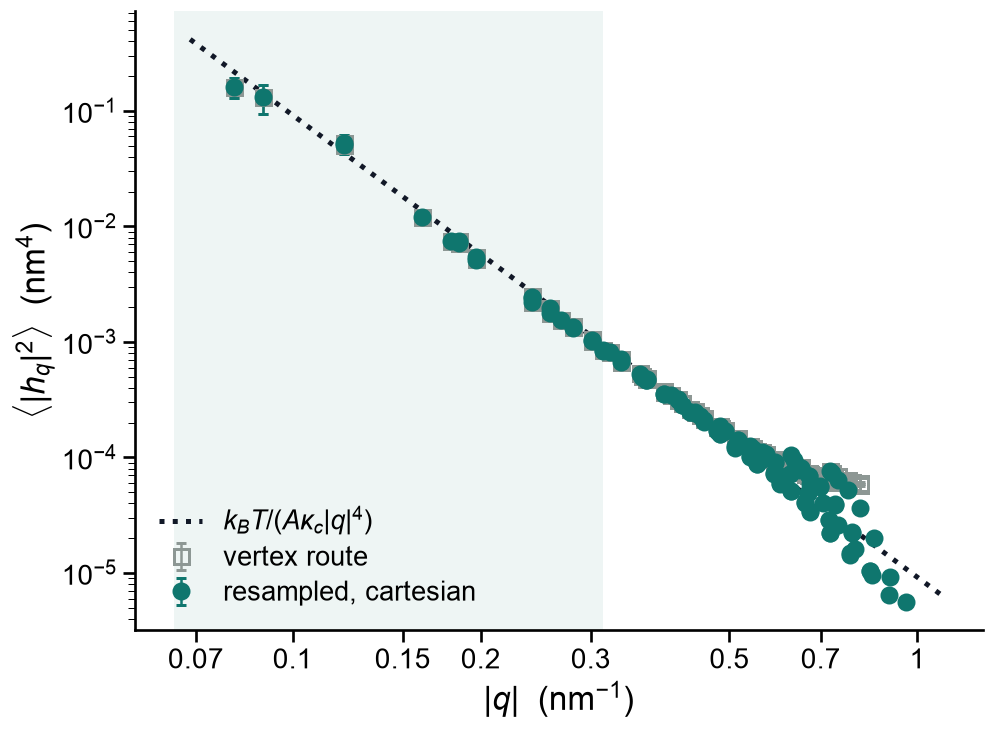

In [12]:
fig, ax = plt.subplots(figsize=(8.6, 6.4))
ax.axvspan(qv.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07, lw=0, zorder=0)
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), ":", color=INK, lw=3.0, zorder=2,
        label=r"$k_BT/(A\kappa_c |q|^4)$")
for tag, colour, mk, off in (("vertex route", GREY, "s", 1.0),
                             ("resampled, cartesian", TEAL, "o", 1.0)):
    r = results[tag]
    ax.errorbar(r["q"], r["S"] * off, yerr=r["E"] * off, fmt=mk, ms=9,
                mfc="none" if mk == "s" else colour, mec=colour, ecolor=colour,
                elinewidth=1.5, mew=1.8, lw=0, zorder=4, label=tag)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\langle |h_q|^2 \rangle$  (nm$^4$)")
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

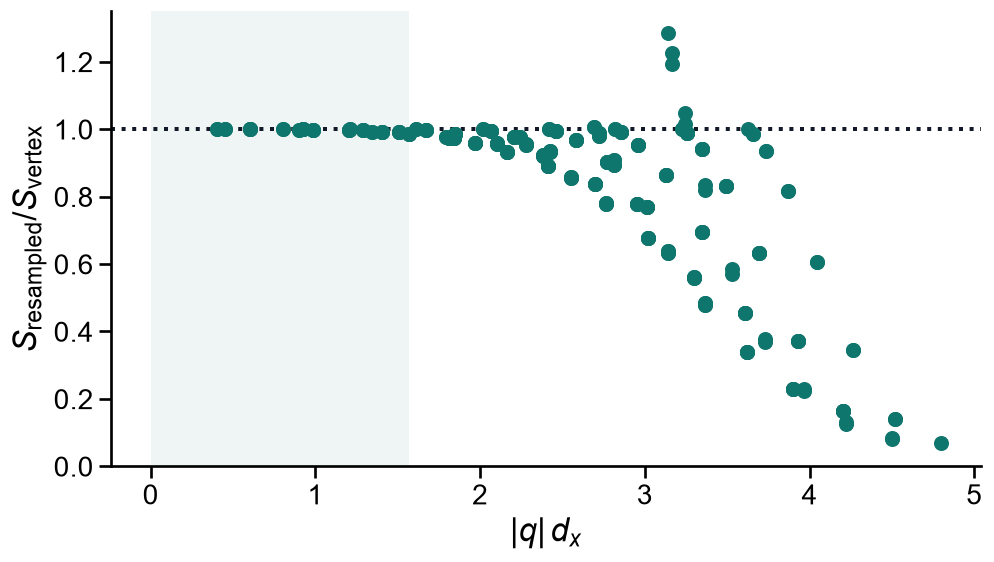

inside the fitting window:  ratio = 0.9984 (range 0.985 - 1.000) over 44 modes
beyond |q|*dx = 3:            ratio = 0.632


In [13]:
# Where do the two samplings actually differ?  Compare bin by bin, using the
# RAW (unfolded) mode index -- both grids have the same bins over the same box.
S_v = ms.power_spectrum(ms.tile_fft2(h_vertex, lat), lat)
S_c = mr.cartesian_spectrum(h_cart, lat)
_, _, q_raw = ms.q_grid(lat, fold_to_brillouin_zone=False)
m = q_raw > 0
qd, ratio = (q_raw * lat.d_face_x)[m], (S_c / S_v)[m]

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.axvspan(0, QDX_MAX, color=TEAL, alpha=0.07, lw=0, zorder=0)
ax.axhline(1.0, color=INK, ls=":", lw=2.4, zorder=2)
ax.plot(qd, ratio, "o", ms=8, mfc=TEAL, mec=TEAL, lw=0, zorder=3)
ax.set_xlabel(r"$|q|\,d_x$")
ax.set_ylabel(r"$S_\mathrm{resampled} / S_\mathrm{vertex}$")
ax.set_ylim(0, 1.35)
plt.tight_layout()
plt.show()

w = qd <= QDX_MAX
print(f"inside the fitting window:  ratio = {np.median(ratio[w]):.4f} "
      f"(range {ratio[w].min():.3f} - {ratio[w].max():.3f}) over {w.sum()} modes")
print(f"beyond |q|*dx = 3:            ratio = {np.median(ratio[qd > 3]):.3f}")

The two routes agree to a fraction of a per cent wherever the measurement is
made, and diverge only past the fitting window. That is the expected answer, not
a disappointment: the limit surface is **not band-limited**, so two different
sample sets of the same surface alias differently, and they do it worst where
the mesh barely resolves the surface at all. Inside $|q|\,d_x \le \pi/2$ — four
cells per wavelength — the disagreement is below the error bars.

So resampling is a generalisation of the vertex route, not a correction to it.
Which raises the obvious question: what is it *for*?

---
## 6. The $\kappa_c$ plot

Dividing the measured spectrum back through the law gives an effective bending
modulus per mode,

$$\kappa_c^{\mathrm{eff}}(|q|) \;=\;
\frac{k_BT}{A\,|q|^4\,\langle|h_{\mathbf q}|^2\rangle}$$

flat at the input $\kappa_c$ wherever the law holds. This is a far more
sensitive read than the log–log slope: a 10% amplitude error is invisible over
four decades of $\langle|h_{\mathbf q}|^2\rangle$ and obvious here.

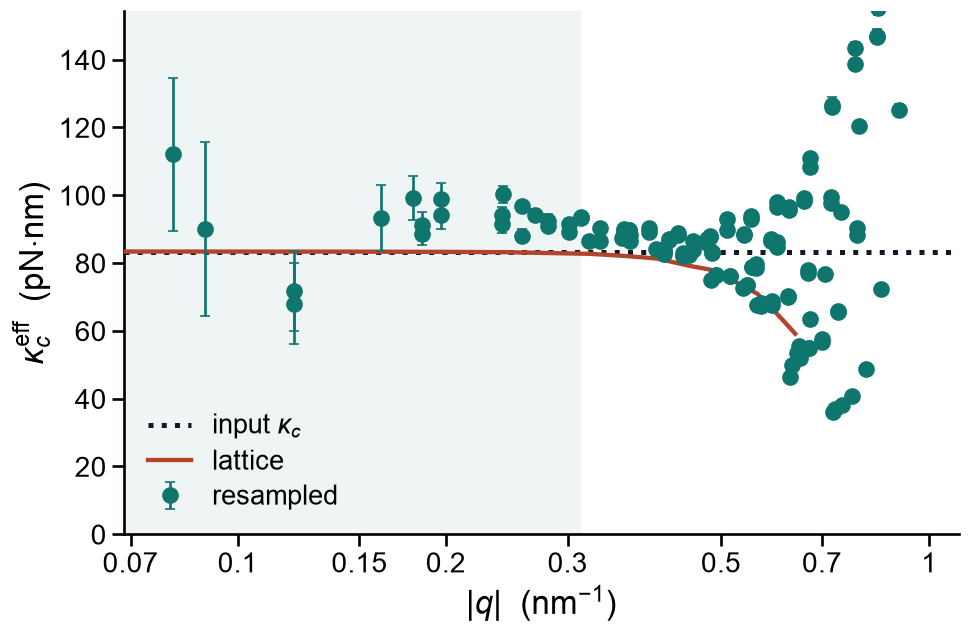

mean kc inside the window: 92.0 +/- 1.9 pN.nm (input 83.4)


In [14]:
kc_eff = KBT / (lat.area * qv ** 4 * Sv)
kc_err = kc_eff * (Ev / Sv)

fig, ax = plt.subplots(figsize=(8.4, 5.6))
ax.axvspan(qv.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07,
           lw=0, zorder=0)
ax.axhline(KC_IN, color=INK, lw=3.0, ls=":", zorder=2, label=r"input $\kappa_c$")
qm = qq[qq * lat.d_face_x <= FORM_FACTOR[-1, 0]]   # only where it was measured
ax.plot(qm, KC_IN * form_factor(qm, lat.d_face_x), "-", color=BRICK, lw=2.6,
        zorder=3, label="lattice")
ax.errorbar(qv, kc_eff, yerr=kc_err, fmt="o", ms=9, mfc=TEAL, mec=TEAL,
            ecolor=TEAL, elinewidth=1.6, lw=0, zorder=4, label="resampled")

ax.set_xscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\kappa_c^{\mathrm{eff}}$  (pN$\cdot$nm)")
ax.set_xlim(qv.min() * 0.85, qv.max() * 1.15)
ax.set_ylim(0, KC_IN * 1.85)
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"mean kc inside the window: {kc_eff[win].mean():.1f} +/- "
      f"{kc_eff[win].std(ddof=1) / np.sqrt(win.sum()):.1f} pN.nm (input {KC_IN})")

The red curve is not fitted: it is the input $\kappa_c$ times the statically
measured lattice form factor, drawn only over the range that measurement
covers. It accounts for most of the roll-off outside the window; the last few
modes fall further still, which is the corner of the Brillouin zone where the
transform is marginal and where no fit should go anyway.

### How much trajectory does this need?

The lowest-$|q|$ mode relaxes as $|q|^{-4}$, so it converges
last; a run that has not sampled it reads *low* and drags the slope towards
zero. Refitting from growing prefixes of the same trajectory shows where it
settles.

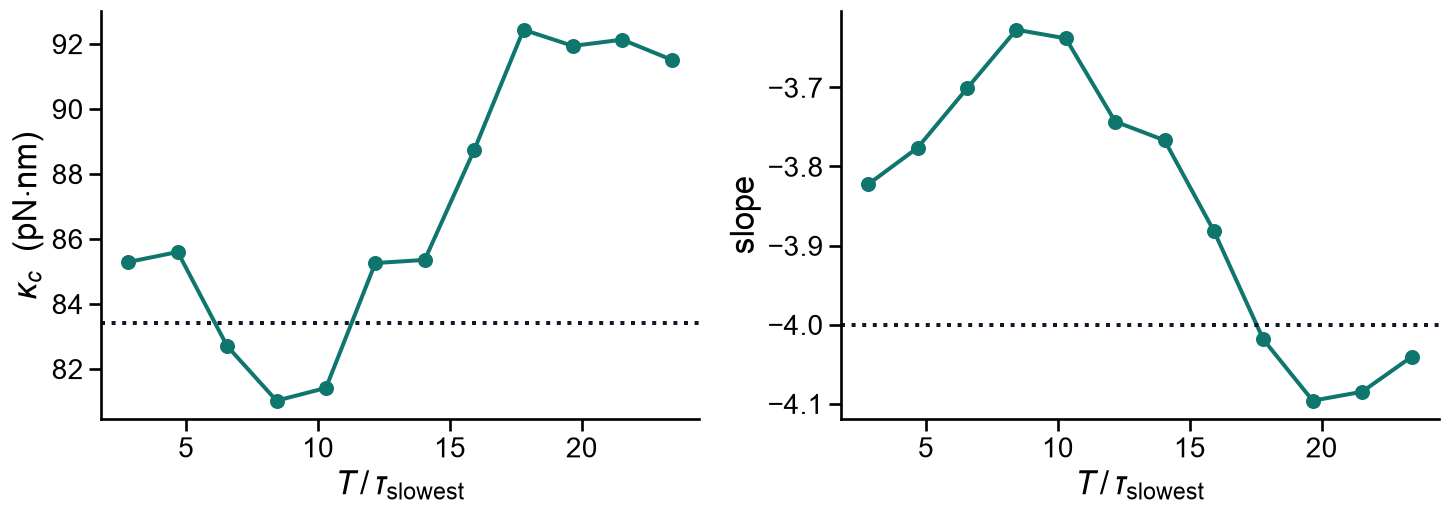

slowest mode: tau = 55 us; analysed window is 23 of those


In [15]:
fracs = np.linspace(0.12, 1.0, 12)
rows = []
for f in fracs:
    n = int(len(h_cart) * f)
    Sf, _ = block_power(np.fft.fft2(h_cart[:n], axes=(-2, -1)), lat, nblock=4)
    sv = Sf[keep][order]
    kc_f, _ = ms.fit_kc_sigma(qv[win], sv[win], lat.area, KBT)
    sl = np.polyfit(np.log10(qv[win]), np.log10(sv[win]), 1)[0]
    rows.append((n * DT_FRAME, sl, kc_f))
rows = np.array(rows)

tau_slow = KBT / (DIFF * A_CELL * KC_IN * qv.min() ** 4)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
for ax, col, ref, lab in ((axes[0], 2, KC_IN, r"$\kappa_c$  (pN$\cdot$nm)"),
                          (axes[1], 1, -4.0, "slope")):
    ax.plot(rows[:, 0] / tau_slow, rows[:, col], "o-", color=TEAL, ms=8, lw=2.4)
    ax.axhline(ref, color=INK, lw=2.4, ls=":")
    ax.set_xlabel(r"$T\,/\,\tau_{\mathrm{slowest}}$")
    ax.set_ylabel(lab)
plt.tight_layout()
plt.show()

print(f"slowest mode: tau = {tau_slow:.0f} us; analysed window is "
      f"{len(h_cart) * DT_FRAME / tau_slow:.0f} of those")

---
## 7. What area elasticity does

The shipped `input.params` sets `usMembraneStretching` = $\mu_S$ = 250 pN/nm
against a reference area pinned to the *flat* starting area. Fluctuations buy
excess area the constraint pulls back, so a real tension develops and the
spectrum crosses over from $|q|^{-4}$ to $|q|^{-2}$ below
$|q| = q^{*} \equiv \sqrt{\sigma/\kappa_c}$. No analysis can recover
$|q|^{-4}$ from that, and resampling is no exception -- the point of
showing it here is that the resampled route measures the same crossover, not
that it rescues anything.

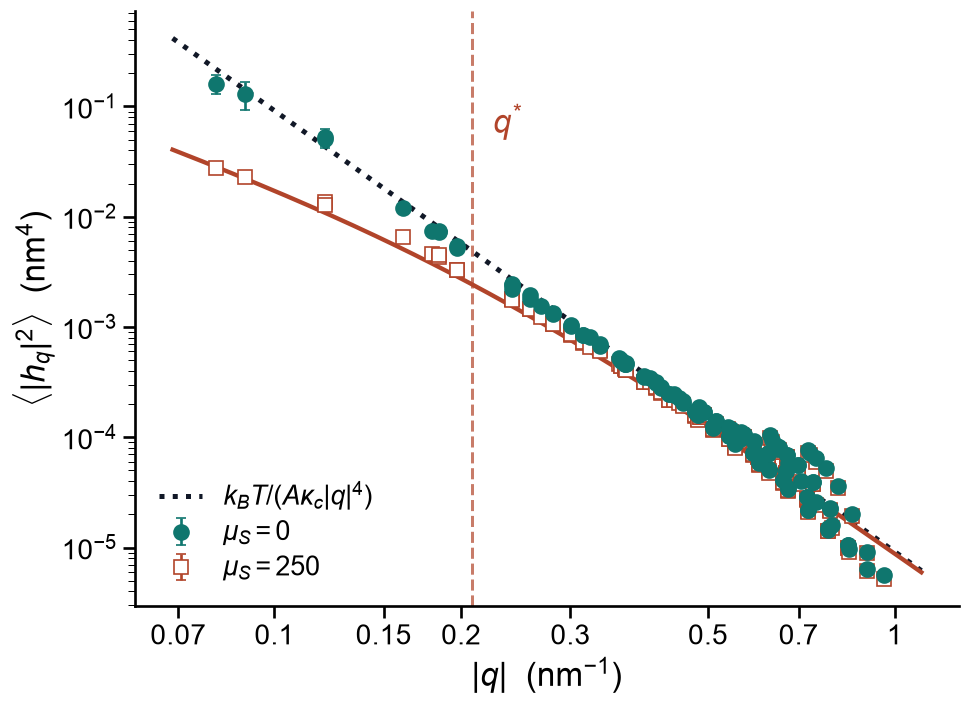

fitted sigma = 3.62 pN/nm, crossover q* = 0.208 /nm, slope over the window = -2.80
predicted sigma from kBT*muS/(4 pi kc) * ln(nFaceX) = 2.98 pN/nm


In [16]:
def load_resampled(run_dir, start=0, max_frames=None, burn_frac=0.2):
    """Read a run and resample it onto its own cartesian Monge grid.

    Each run gets its own LimitSurface, because the grid is anchored to that
    run's control net.  The parameter solve is done once and reused for every
    frame, so the cost here is dominated by reading the CSV.
    """
    lat_ = ms.lattice_from_params(run_dir / "input.params")
    p = {}
    for line in open(run_dir / "input.params"):
        if "=" in line and not line.strip().startswith("#"):
            k, v = line.split("=", 1)
            p[k.strip()] = v.split("#")[0].strip()
    dtf = float(p["timeStep"]) * int(p.get("meshpointOutputInterval", 1))
    s_ = mr.LimitSurface(lat_, mr.reference_net(run_dir / "meshpointinput.csv", lat_))
    R_ = s_.solve(*s_.monge_grid("cartesian"))
    zz = ms.read_tile_heights(run_dir / "meshpointinput.csv", lat_,
                              start=start, max_frames=max_frames)
    return R_.apply(zz)[int(len(zz) * burn_frac):], dtf, lat_


TENSION = RUNS / "tension"
US_IN = 250.0
ht, _, lat_t = load_resampled(TENSION)
assert (lat_t.nx, lat_t.ny) == (lat.nx, lat.ny)

St2d, Et2d = block_power(np.fft.fft2(ht, axes=(-2, -1)), lat_t)
Svt, Evt = St2d[keep][order], Et2d[keep][order]
kct, sigt = ms.fit_kc_sigma(qv[win], Svt[win], lat.area, KBT)
q_star = np.sqrt(max(sigt, 0) / KC_IN)

fig, ax = plt.subplots(figsize=(8.4, 6.2))
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), ":", color=INK, lw=3.0,
        zorder=2, label=r"$k_BT/(A\kappa_c |q|^4)$")
ax.plot(qq, KBT / (lat.area * (KC_IN * qq ** 4 + sigt * qq ** 2)), "-",
        color=BRICK, lw=2.6, zorder=2)
ax.errorbar(qv, Sv, yerr=Ev, fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.6, lw=0, zorder=4, label=r"$\mu_S = 0$")
ax.errorbar(qv, Svt, yerr=Evt, fmt="s", ms=8, mfc="white", mec=BRICK,
            ecolor=BRICK, elinewidth=1.6, lw=0, zorder=3, label=r"$\mu_S = 250$")
ax.axvline(q_star, color=BRICK, lw=1.8, ls="--", alpha=0.7, zorder=1)
ax.text(q_star * 1.08, Sv.max() * 0.35, r"$q^{*}$", color=BRICK, fontsize=20)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\langle |h_q|^2 \rangle$  (nm$^4$)")
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

slope_t = np.polyfit(np.log10(qv[win]), np.log10(Svt[win]), 1)[0]
print(f"fitted sigma = {sigt:.2f} pN/nm, crossover q* = {q_star:.3f} /nm, "
      f"slope over the window = {slope_t:+.2f}")
print(f"predicted sigma from kBT*muS/(4 pi kc) * ln(nFaceX) = "
      f"{KBT * US_IN / (4 * np.pi * KC_IN) * np.log(lat.n_face_x):.2f} pN/nm")

Between $|q|^{-2}$ at the low end and $|q|^{-4}$ at the high
end, the window-averaged slope lands near $-2.8$ — not a power law at all, just
the crossover caught mid-turn. That is the honest reading of a tense sheet, and
the reason the $\mu_S = 0$ run is the one used for $\kappa_c$.

---
## 8. Time decorrelation: $\langle h_{\mathbf q}(t)\,h^*_{\mathbf q}(t+\tau)\rangle$

Each mode is an Ornstein–Uhlenbeck process, so its autocorrelation is a single
exponential,

$$C_{\mathbf q}(\tau)\;=\;
\frac{\langle h_{\mathbf q}(t)\,h^*_{\mathbf q}(t+\tau)\rangle}
{\langle|h_{\mathbf q}|^2\rangle}\;=\;e^{-\Gamma(|q|)\,\tau}$$

and **all** the information about the solvent is in $\Gamma(|q|)$ — the
static spectrum above has no mobility in it at all. Two candidate laws:

| | mobility | rate |
| --- | --- | --- |
| free draining (what SLIMED implements) | $\Lambda = Da/k_BT$, a per-vertex scalar | $\Gamma = \Lambda\,\kappa_c |q|^4$ |
| Oseen / Zimm hydrodynamics | $\Lambda(|q|) = 1/4\eta|q|$ | $\Gamma = \kappa_c |q|^3/4\eta$ |

$\tau_q$ spans four orders of magnitude across the zone, so no single
output interval resolves all of it: a trajectory written every 100 steps cannot
time a mode that decorrelates in three, and one written every step is too short
to time the slowest. Both runs are used, each over the part of the band it
resolves.

In [17]:
# Long run for the slow modes, every-step run for the fast ones.  The long one
# is the array section 5 already resampled -- read at full time resolution, so
# its frame interval is DT_FRAME and no rescaling is needed.
h_slow, dt_slow = h_cart, DT_FRAME
h_fast, dt_fast, _ = load_resampled(RUNS / "fast_test", burn_frac=0.25)
print(f"long : {len(h_slow):6d} frames x {dt_slow} us = {len(h_slow) * dt_slow:.0f} us")
print(f"short: {len(h_fast):6d} frames x {dt_fast} us = {len(h_fast) * dt_fast:.0f} us")

long :   6401 frames x 0.2 us = 1280 us
short:  45001 frames x 0.002 us = 90 us


In [18]:
# Only trust a mode the record resolves at BOTH ends: its correlation time must
# span several output intervals (or the sampling rate is what is measured) and
# fit many times into the block (or subtracting the block mean eats the
# signal).  Everything else comes back as nan and simply does not plot.
MIN_LAGS = 3.0        # tau >= 3 output intervals
MIN_SAMPLES = 25.0    # block >= 25 correlation times


def cart_fft(h):
    """The transform for a field already on a rectangular grid."""
    return np.fft.fft2(h, axes=(-2, -1))


def block_rates(h_frames, lat, dtf, nblock=NBLOCK):
    """Per-mode Gamma and its standard error over equal time blocks."""
    n = len(h_frames)
    edges = np.linspace(0, n, nblock + 1).astype(int)
    per = np.full((nblock, lat.ny, lat.nx), np.nan)
    for b, (a, c) in enumerate(zip(edges[:-1], edges[1:])):
        nb = c - a
        acf = ms.mode_autocorrelation(cart_fft(h_frames[a:c]),
                                      max_lag=max(4, nb // 3))
        for iy in range(lat.ny):
            for ix in range(lat.nx):
                per[b, iy, ix] = ms.relaxation_rate(
                    acf[:, iy, ix], dtf, n_frames=nb,
                    max_tau_fraction=1.0 / MIN_SAMPLES, min_lags=MIN_LAGS)
    cnt = np.isfinite(per).sum(axis=0)
    # A mode no block could time is all-nan; that is the answer, not a warning.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = np.nanmean(per, axis=0)
        sem = np.nanstd(per, axis=0, ddof=1) / np.sqrt(np.maximum(cnt, 1))
    mean[cnt < 3] = np.nan
    sem[cnt < 3] = np.nan
    return mean, sem


g_slow, ge_slow = block_rates(h_slow, lat, dt_slow)
g_fast, ge_fast = block_rates(h_fast, lat, dt_fast)
for nm, g in (("long", g_slow), ("short", g_fast)):
    ok = np.isfinite(g)
    band = (f"|q| = {q_cart[ok].min():.3f} .. {q_cart[ok].max():.3f} nm^-1" if ok.any()
            else "none in the band this record resolves")
    print(f"{nm:>5} run: {ok.sum():3d}/{(q_cart > 0).sum()} modes resolved, {band}")

 long run:  20/251 modes resolved, |q| = 0.161 .. 0.258 nm^-1
short run: 231/251 modes resolved, |q| = 0.241 .. 0.960 nm^-1


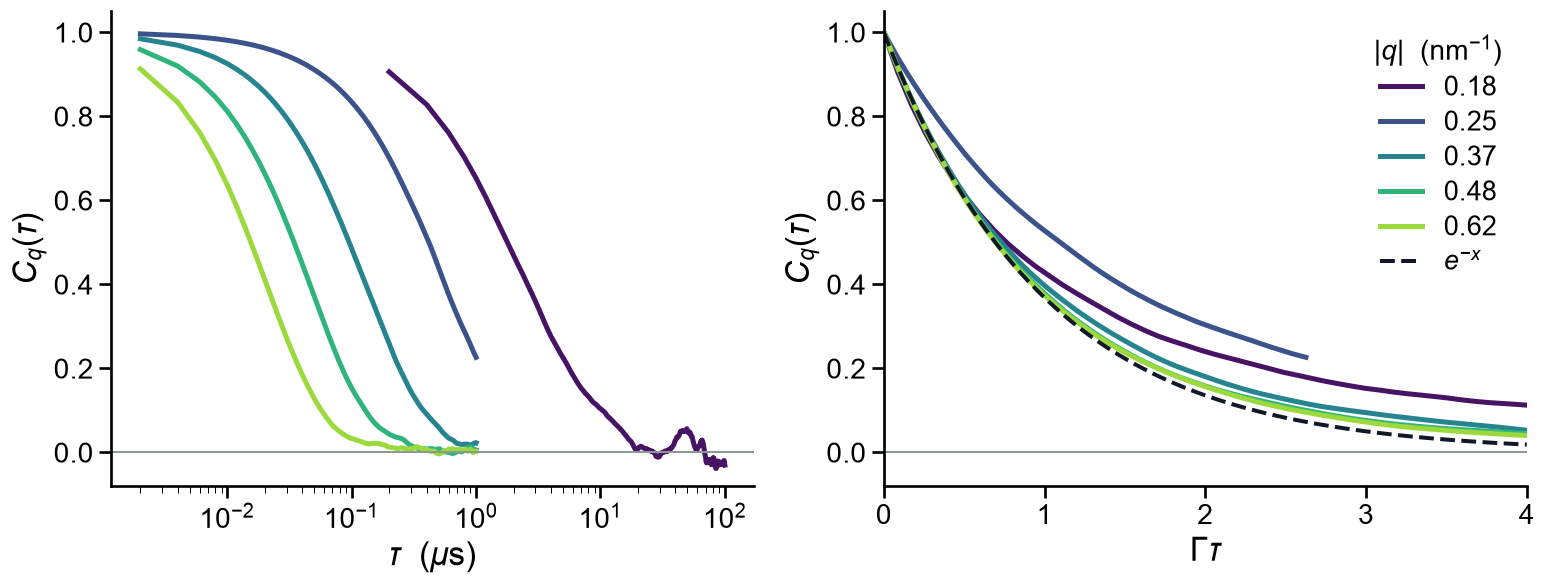

In [19]:
def shell_acf(h_frames, lat, dtf, lo, hi, max_lag=500):
    """Autocorrelation averaged over the modes in one |q| shell."""
    m = (q_cart > lo) & (q_cart <= hi)
    acf = ms.mode_autocorrelation(cart_fft(h_frames),
                                  max_lag=min(max_lag, len(h_frames) // 3))
    return acf[:, m].mean(axis=1), q_cart[m].mean()


shells = [(0.155, 0.20, h_slow, dt_slow, g_slow),
          (0.24,  0.27, h_fast, dt_fast, g_fast),
          (0.34,  0.39, h_fast, dt_fast, g_fast),
          (0.45,  0.50, h_fast, dt_fast, g_fast),
          (0.60,  0.65, h_fast, dt_fast, g_fast)]
cmap = plt.cm.viridis(np.linspace(0.05, 0.85, len(shells)))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2))
for (lo, hi, hh, dtf, grid), colour in zip(shells, cmap):
    with warnings.catch_warnings():   # a shell no block could time is all-nan
        warnings.simplefilter("ignore", RuntimeWarning)
        rate = np.nanmean(grid[(q_cart > lo) & (q_cart <= hi)])
    if not np.isfinite(rate):
        continue
    c, qm = shell_acf(hh, lat, dtf, lo, hi)
    tau = np.arange(len(c)) * dtf
    axes[0].plot(tau[1:], c[1:], color=colour, lw=3.0, label=f"{qm:.2f}")
    axes[1].plot(tau * rate, c, color=colour, lw=3.0, label=f"{qm:.2f}")

x = np.linspace(0, 4, 80)
axes[1].plot(x, np.exp(-x), "--", color=INK, lw=2.4, label=r"$e^{-x}$")
axes[1].set_xlim(0, 4)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\tau$  ($\mu$s)")
axes[1].set_xlabel(r"$\Gamma\tau$")
for ax in axes:
    ax.axhline(0, color=GREY, lw=1.2)
    ax.set_ylabel(r"$C_q(\tau)$")
    ax.set_ylim(-0.08, 1.05)
axes[1].legend(title=r"$|q|$  (nm$^{-1}$)", loc="upper right")
plt.tight_layout()
plt.show()

Single exponentials that collapse onto $e^{-x}$ once time is rescaled by each
shell's own rate — which is what an overdamped mode should do, and a check that
nothing in the sampling, or in the resampling, is distorting the correlation.
The rates themselves are the interesting part.

---
## 9. The rate: $\Gamma$ against $|q|$

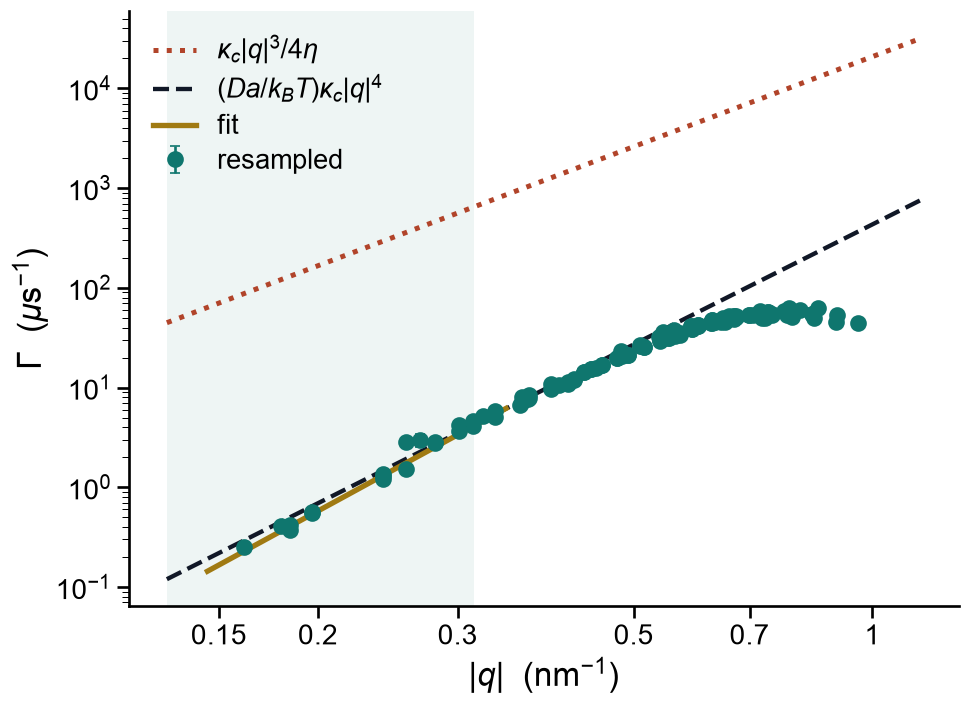

123 modes, |q| = 0.161 .. 0.960 nm^-1
log-log slope inside the window : +4.34   (+4 free draining, +3 Oseen)
median Gamma / free draining    : 0.91
median Gamma / Oseen            : 4.5e-03


In [20]:
LAMBDA = DIFF * A_CELL / KBT          # nm^3/(pN us) -- the code's own mobility
ETA = 1.0e-3                          # pN.us/nm^2   (= 1 mPa.s, water)

# one point per independent mode, taken from whichever run resolves it
g_all = np.where(np.isfinite(g_slow), g_slow, g_fast)
ge_all = np.where(np.isfinite(g_slow), ge_slow, ge_fast)
ok = keep & np.isfinite(g_all)
qg, gg, ge = q_cart[ok], g_all[ok], ge_all[ok]
o = np.argsort(qg)
qg, gg, ge = qg[o], gg[o], ge[o]

gwin = qg * lat.d_face_x <= QDX_MAX
wg = gg[gwin] / np.maximum(ge[gwin], 1e-30)
gslope, gicept = np.polyfit(np.log10(qg[gwin]), np.log10(gg[gwin]), 1, w=wg)

fig, ax = plt.subplots(figsize=(8.4, 6.2))
ql = np.logspace(np.log10(qg.min() * 0.8), np.log10(qg.max() * 1.2), 200)
ax.plot(ql, KC_IN * ql ** 3 / (4 * ETA), ":", color=BRICK, lw=3.0, zorder=2,
        label=r"$\kappa_c |q|^3/4\eta$")
ax.plot(ql, LAMBDA * KC_IN * ql ** 4, "--", color=INK, lw=2.6, zorder=2,
        label=r"$(Da/k_BT)\kappa_c |q|^4$")
qfit = np.logspace(np.log10(qg[gwin].min() * 0.9),
                   np.log10(qg[gwin].max() * 1.1), 50)
ax.plot(qfit, 10 ** gicept * qfit ** gslope, "-", color=OCHRE, lw=3.2, zorder=3,
        label="fit")
ax.errorbar(qg, gg, yerr=ge, fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.6, lw=0, zorder=4, label="resampled")
ax.axvspan(qg.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07,
           lw=0, zorder=0)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)")
ax.set_ylabel(r"$\Gamma$  ($\mu$s$^{-1}$)")
nice_logx(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

pred = LAMBDA * KC_IN * qg ** 4
oseen = KC_IN * qg ** 3 / (4 * ETA)
print(f"{len(qg)} modes, |q| = {qg.min():.3f} .. {qg.max():.3f} nm^-1")
print(f"log-log slope inside the window : {gslope:+.2f}   "
      "(+4 free draining, +3 Oseen)")
print(f"median Gamma / free draining    : {np.median((gg / pred)[gwin]):.2f}")
print(f"median Gamma / Oseen            : {np.median((gg / oseen)[gwin]):.1e}")

The fitted exponent is $+4$, the mirror of the $-4$ in the static spectrum:
$\Gamma\propto|q|^4$ means $\tau_q\propto|q|^{-4}$.
The points sit on the dashed line, which is drawn from the run's *own*
`diffConst`, area per vertex and `kcMembraneBending` — no fitted prefactor in it
— and two to three orders of magnitude below the dotted Oseen line.

That is not a near miss to be tuned away. `DynamicModel::next_step()` displaces
each vertex by $(D\,\mathrm{d}t/k_BT)F_i + \sqrt{2D\,\mathrm{d}t}\,\xi_i$: a
scalar mobility, per vertex, independent of every other vertex. There is no
Oseen tensor and no mobility matrix anywhere in the repository, so
$\Gamma\propto|q|^4$ is what the integrator *is*, and a
$|q|^{-3}$ decorrelation cannot come out of it however the trajectory is
analysed — resampled or not.

Two things to know before reading any absolute timescale out of this model:

* **`diffConst` is not tied to a solvent.** It is a free per-vertex parameter in
  nm$^2/\mu$s, so absolute relaxation times are arbitrary until it is
  calibrated.
* **The free-draining rate is mesh dependent.**
  $\Gamma = (Da/k_BT)\kappa_c|q|^4$ is proportional to the area per
  vertex, so refining the mesh at fixed $D$ slows the dynamics by the refinement
  factor squared. The quantity to hold fixed for mesh-convergent dynamics is the
  mobility *per unit area*, $\Lambda = Da/k_BT$.

`analysis/reference_langevin.py` integrates the same Langevin equation directly
in Fourier space and reproduces both limbs: identical static spectra, a $\Gamma$
exponent of $3.84$ with the local mobility and $2.93$ with Oseen.

---
## 10. What it is for: vertices that move

The experiment holds the **membrane fixed** and moves only the sampling
positions, which is exactly the question at issue. The run's own limit surface
$S$ is the truth. If a vertex had drifted to $\mathbf r_k + \boldsymbol\delta_k$,
the height its trajectory records is $S$ evaluated *there* — a perfectly good
sample of the same membrane, at a displaced point.

So: use the resampler to generate what a drifted vertex set would have written,
then read it two ways.

- **vertex route** — feed those heights to `tile_fft2`, which labels them with
  the ideal lattice positions, because that is all it can do.
- **resampled** — read the same surface on the fixed cartesian grid, which needs
  no assumption about where the vertices went.

This isolates the *measurement* error. A real run with mobile vertices would
also have different dynamics; that is a separate question, and this notebook
does not answer it.

In [21]:
# The baseline is the vertex route with no drift at all -- i.e. exactly what
# membrane_fluctuations_cpu.ipynb measures.  Everything is compared against
# that, so what is plotted is the drift error alone and not the difference
# between the two sampling grids, which section 5 already accounted for.
z_small = z_eq[::max(1, len(z_eq) // 200)]        # ~200 frames, whatever the run length
_, _, q_tri = ms.q_grid(lat)
win = keep & (q_tri * lat.d_face_x <= QDX_MAX)
tail = keep & (q_tri * lat.d_face_x > 2.5)


def vertex_route(h):
    return ms.power_spectrum(ms.tile_fft2(h, lat), lat)


base = vertex_route(surf.solve(X_zig, Y_zig).apply(z_small))
rng = np.random.default_rng(2024)


def displaced(sigma, per_frame):
    """Heights a drifted vertex set would have written, for the same surface."""
    if not sigma:
        return surf.solve(X_zig, Y_zig).apply(z_small)
    if not per_frame:                      # one offset, held for the whole run
        dX = rng.normal(scale=sigma, size=X_zig.shape)
        dY = rng.normal(scale=sigma, size=Y_zig.shape)
        return surf.solve(X_zig + dX, Y_zig + dY).apply(z_small)
    h = np.empty_like(z_small)             # redrawn every frame
    for t in range(len(z_small)):
        dX = rng.normal(scale=sigma, size=X_zig.shape)
        dY = rng.normal(scale=sigma, size=Y_zig.shape)
        h[t] = surf.solve(X_zig + dX, Y_zig + dY).apply(z_small[t])
    return h


sigmas = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
drift = []
print(f"{len(z_small)} frames.  ratios are against the same route with no drift.\n")
print(f"{'sigma':>9} {'% cell':>8} | {'frozen offset':>22} | {'redrawn each frame':>22}")
print(f"{'':>9} {'':>8} | {'kc':>10} {'tail':>11} | {'kc':>10} {'tail':>11}")
for sigma in sigmas:
    row = {"sigma": sigma}
    for tag, per_frame in (("frozen", False), ("moving", True)):
        S_d = vertex_route(displaced(sigma, per_frame))
        row[tag + "_kc"] = np.mean(KBT / (lat.area * q_tri[win] ** 4 * S_d[win]))
        row[tag + "_tail"] = np.median((S_d / base)[tail])
    drift.append(row)
    print(f"{sigma:8.2f}nm {sigma / lat.d_face_x:7.1%} | {row['frozen_kc']:10.2f} "
          f"{row['frozen_tail']:10.2f}x | {row['moving_kc']:10.2f} "
          f"{row['moving_tail']:10.2f}x")

print(f"\nboth read 1.00x at sigma = 0, which is the check that the comparison is fair.")
print("The resampled route does not appear in this table because it has no entry to")
print("make: it evaluates the surface at the positions asked for, so its answer is")
print("the sigma = 0 row whatever the vertices do -- provided the trajectory records")
print("where they went, which it does, in the x and y columns nothing currently reads.")

201 frames.  ratios are against the same route with no drift.

    sigma   % cell |          frozen offset |     redrawn each frame
                   |         kc        tail |         kc        tail
    0.00nm    0.0% |      92.42       1.00x |      92.42       1.00x


    0.05nm    1.0% |      92.45       1.00x |      92.39       1.00x


    0.10nm    2.0% |      92.49       1.00x |      92.53       1.00x


    0.25nm    5.0% |      92.47       1.02x |      92.41       1.02x


    0.50nm   10.0% |      93.13       1.09x |      92.87       1.08x


    1.00nm   20.0% |      94.48       1.36x |      94.38       1.45x

both read 1.00x at sigma = 0, which is the check that the comparison is fair.
The resampled route does not appear in this table because it has no entry to
make: it evaluates the surface at the positions asked for, so its answer is
the sigma = 0 row whatever the vertices do -- provided the trajectory records
where they went, which it does, in the x and y columns nothing currently reads.


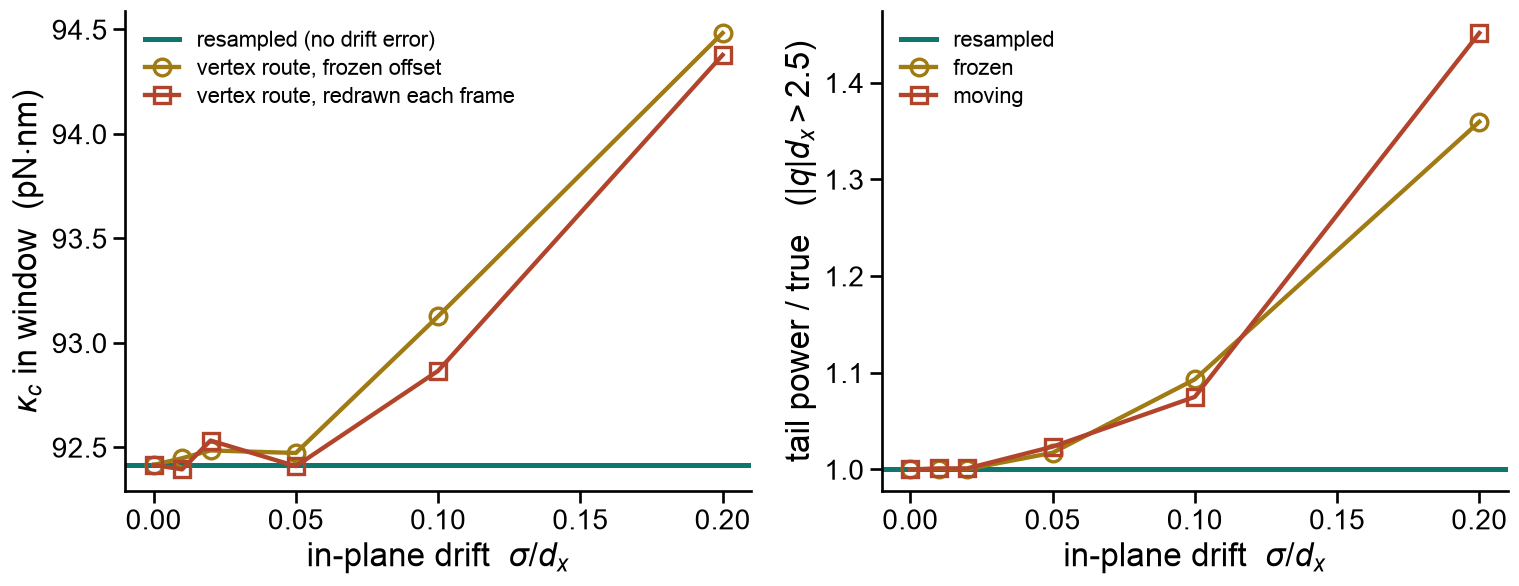

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
s = np.array([d["sigma"] for d in drift]) / lat.d_face_x

ax = axes[0]
ax.axhline(drift[0]["frozen_kc"], color=TEAL, lw=3.0, zorder=2,
           label="resampled (no drift error)")
for tag, colour, mk, lbl in (("frozen", OCHRE, "o", "vertex route, frozen offset"),
                             ("moving", BRICK, "s", "vertex route, redrawn each frame")):
    ax.plot(s, [d[tag + "_kc"] for d in drift], mk + "-", color=colour, mfc="none",
            mew=2.0, ms=10, zorder=3, label=lbl)
ax.set_xlabel(r"in-plane drift  $\sigma / d_x$")
ax.set_ylabel(r"$\kappa_c$ in window  (pN$\cdot$nm)")
ax.legend(loc="upper left", fontsize=13)

ax = axes[1]
ax.axhline(1.0, color=TEAL, lw=3.0, zorder=2, label="resampled")
for tag, colour, mk in (("frozen", OCHRE, "o"), ("moving", BRICK, "s")):
    ax.plot(s, [d[tag + "_tail"] for d in drift], mk + "-", color=colour, mfc="none",
            mew=2.0, ms=10, zorder=3, label=tag)
ax.set_xlabel(r"in-plane drift  $\sigma / d_x$")
ax.set_ylabel(r"tail power / true   ($|q| d_x > 2.5$)")
ax.legend(loc="upper left", fontsize=13)

for ax in axes:
    ax.set_xlim(-0.01, s.max() * 1.05)
plt.tight_layout()
plt.show()

The fitting window is robust either way: $\kappa_c$ barely moves, because those
modes carry almost all the power and a small phase error costs them little. The
tail is what degrades, and it degrades in the direction that matters -- upward,
faking power in the modes that have almost none of their own.

The two cases bracket what a real drift would do: a **frozen** offset is a fixed
distortion that partly survives the time average, and displacements **redrawn
each frame** are the fully decorrelated limit. In practice they come out close,
with the redrawn case worse only once the drift is a sizeable fraction of a
cell, so the answer does not hinge on which of the two a moving mesh resembles.
Lateral diffusion would sit between them.

That is the case for resampling. Not that the current numbers are wrong -- they
are not, and section 3 shows the two routes agreeing to machine precision -- but
that their correctness rests on a line in `next_step()` which the analysis has no
way to check, and which is the first thing a move beyond the Monge gauge would
delete.

---
## 11. Limits

**Folds.** The Monge gauge presumes the surface is a graph over the plane. Where
the projected control triangles have flipped, no $(v,w)$ maps to a requested
$(x,y)$ and `solve` says so: it flags the point in `.converged`, counts the folds
via `inverted_control_triangles()`, and clamps rather than returning a silently
wrong number. On the runs here the count is zero, and it stays zero up to about
15% of a cell of random in-plane displacement.

**Aliasing.** Resampling does not create information. The limit surface is not
band-limited, so a grid finer than the mesh (`factor > 1`) resolves the box
spline better but tells you nothing new about the membrane above $|q| d_x = \pi$.

**Not yet exercised in anger.** Every vertex in the tile has valence 6, so only
the regular 12-node patch is implemented. An extraordinary vertex — which a
non-flat topology or an adaptively refined mesh would introduce — needs the
irregular patch and the subdivision matrices in
`src/mesh/Subdivision_matrices.cpp`. `set_one_ring_vertices_sorted()` already
builds rings of any valence, so the C++ side is ready; this module is not.

**Cost.** ~15 us per grid point for the exact solve, once, while the in-plane
geometry is frozen. If it stops being frozen, the solve has to be redone per
frame: about 4 ms per frame for this tile, half a minute for an 8000-frame run.
Still not the bottleneck — reading the CSV is.